**Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import  mean_absolute_error,mean_squared_error,r2_score
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings("ignore")

**Load Dataset**

In [2]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


**Data Information**

In [3]:
print(df.shape)

(2640, 12)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None


In [5]:
print(df.describe(include='all'))

               Year        Month  Region    Model  Estimated_Deliveries  \
count   2640.000000  2640.000000    2640     2640           2640.000000   
unique          NaN          NaN       4        5                   NaN   
top             NaN          NaN  Europe  Model S                   NaN   
freq            NaN          NaN     660      528                   NaN   
mean    2020.000000     6.500000     NaN      NaN           9922.199621   
std        3.162877     3.452707     NaN      NaN           3935.950093   
min     2015.000000     1.000000     NaN      NaN             48.000000   
25%     2017.000000     3.750000     NaN      NaN           7292.000000   
50%     2020.000000     6.500000     NaN      NaN           9857.000000   
75%     2023.000000     9.250000     NaN      NaN          12510.250000   
max     2025.000000    12.000000     NaN      NaN          25704.000000   

        Production_Units  Avg_Price_USD  Battery_Capacity_kWh     Range_km  \
count        2640.000

In [6]:
print(df.isnull().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [7]:
duplicates = df.duplicated().sum()
print("Duplicates: ",duplicates)

Duplicates:  0


# Preprocessing

In [8]:
categorical_cols = ['Region', 'Model', 'Source_Type']
df['Date']=pd.to_datetime(dict(year=df.Year,month=df.Month,day=1))
label_encoders = {}
#Label Encoding
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

## EDA

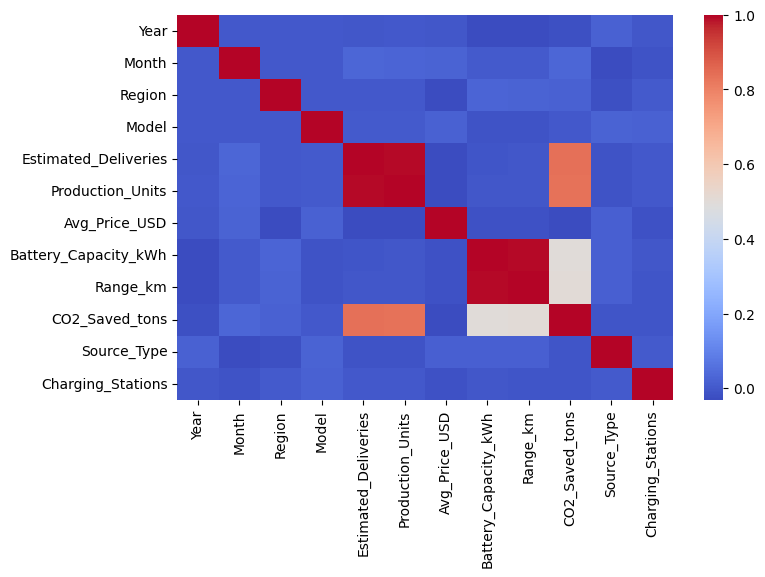

In [9]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True),annot=False,cmap='coolwarm')
plt.show()

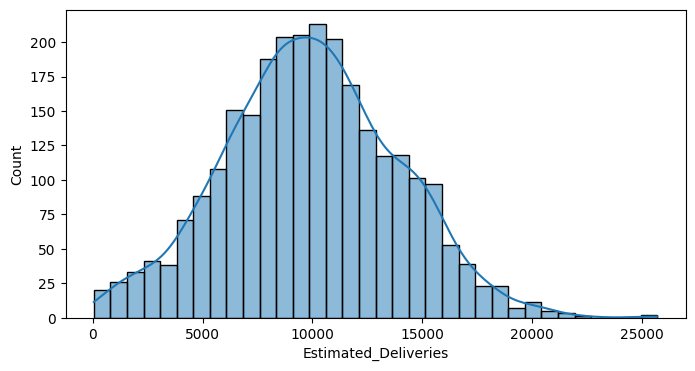

In [10]:
plt.figure(figsize=(8,4))
sns.histplot(df['Estimated_Deliveries'],kde=True)
plt.show()

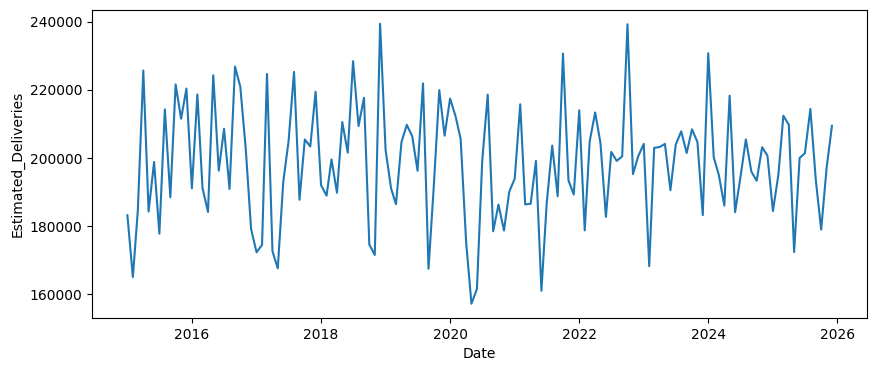

In [11]:
plt.figure(figsize=(10,4))
sns.lineplot(data=df.groupby('Date')['Estimated_Deliveries'].sum().reset_index(),x='Date',y='Estimated_Deliveries')
plt.show()

## Feature Engineering

In [12]:
df['Quarter']=df['Date'].dt.quarter

In [13]:
df['Production_Efficiency']=df['Estimated_Deliveries']/df['Production_Units']

In [14]:
df['Price_per_km']=df['Avg_Price_USD']/df['Range_km']

In [15]:
df['Range_per_kWh'] = df['Range_km'] / df['Battery_Capacity_kWh']

## Model training with hyper parameter tuning

In [16]:
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=['Estimated_Deliveries','Date']),df['Estimated_Deliveries'],test_size=0.2,random_state=42)

In [17]:
X_train

,Year,Month,Region,Model,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Quarter,Production_Efficiency,Price_per_km,Range_per_kWh
2387,2022,2,3,0,11285,50815.14,60,346,548.63,0,10938,1,0.936730,146.864566,5.766667
1187,2019,1,3,4,6229,91420.19,75,419,351.33,1,11000,1,0.897415,218.186611,5.586667
2396,2016,1,0,4,10885,82383.61,82,486,763.99,1,11726,1,0.962793,169.513601,5.926829
440,2020,1,1,3,13257,85609.42,82,460,846.42,0,11937,1,0.925322,186.107435,5.609756
508,2024,4,1,4,17286,58222.35,60,350,804.25,2,7906,2,0.886208,166.349571,5.833333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,2022,8,0,1,17551,57306.00,100,599,1388.81,0,13322,3,0.880691,95.669449,5.990000
1095,2020,11,0,4,1572,62726.59,120,665,150.02,2,11569,4,0.956743,94.325699,5.541667
1130,2025,5,0,1,4093,87971.21,120,717,419.44,2,5472,2,0.952846,122.693459,5.975000
1294,2022,2,2,4,16088,108329.20,60,343,784.92,0,11634,1,0.948284,315.828571,5.716667


In [18]:
y_train

,Estimated_Deliveries
2387,10571
1187,5590
2396,10480
440,12267
508,15319
...,...
1638,15457
1095,1504
1130,3900
1294,15256


**Feature Scaling**
Feature Scaling is doing here because lasso and ridge requires.
Ridge and Lasso add a penalty term to the coefficients. If one feature has much larger values than another, that penalty can unfairly affect the model. That's why scaling is recommended for them.

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Linera Regression  

In [20]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

In [21]:
mae = mean_absolute_error(y_test, pred_lr)
mse = mean_squared_error(y_test, pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred_lr)
print("Linear regression")
print("-"*30)
print("MAE : ",mae)
print("MSE : ",mse)
print("RMSE: ",rmse)
print("R²  : ",r2)

Linear regression
------------------------------
MAE :  108.85279381484452
MSE :  23593.34495245456
RMSE:  153.60125309532654
R²  :  0.9984172219978146


Ridge regression with Hyperparameter tuning

In [22]:
#Hyperparameter Tuning for Ridge Regression
ridge = Ridge()

params = {
    'alpha':[0.01,0.1,1,10,100]
}

grid_ridge = GridSearchCV(
    ridge,
    params,
    cv=5,
    scoring='r2'
)

grid_ridge.fit(X_train_scaled,y_train)

best_ridge = grid_ridge.best_estimator_

pred_ridge = best_ridge.predict(X_test_scaled)

In [23]:
mae = mean_absolute_error(y_test, pred_lr)
mse = mean_squared_error(y_test, pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred_lr)

print("Ridge regression")
print("-"*30)
print("MAE : ",mae)
print("MSE : ",mse)
print("RMSE: ",rmse)
print("R²  : ",r2)

Ridge regression
------------------------------
MAE :  108.85279381484452
MSE :  23593.34495245456
RMSE:  153.60125309532654
R²  :  0.9984172219978146


Lasso Regression with Hyperparameter Tuning

In [24]:
#Hyper parameter tuning used for Lasso regression
lasso = Lasso(max_iter=10000)

params = {
    'alpha':[0.001,0.01,0.1,1,10]
}

grid_lasso = GridSearchCV(
    lasso,
    params,
    cv=5,
    scoring='r2'
)

grid_lasso.fit(X_train_scaled,y_train)

best_lasso = grid_lasso.best_estimator_

pred_lasso = best_lasso.predict(X_test_scaled)

In [25]:
mae = mean_absolute_error(y_test, pred_lr)
mse = mean_squared_error(y_test, pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred_lr)



print("Lasso regression")
print("-"*30)
print("MAE : ",mae)
print("MSE : ",mse)
print("RMSE: ",rmse)
print("R²  : ",r2)

Lasso regression
------------------------------
MAE :  108.85279381484452
MSE :  23593.34495245456
RMSE:  153.60125309532654
R²  :  0.9984172219978146


## Time Series Forecasting

ADF Statistic: -8.796891845702463
p-value: 2.1642553612092046e-14
Series is Stationary


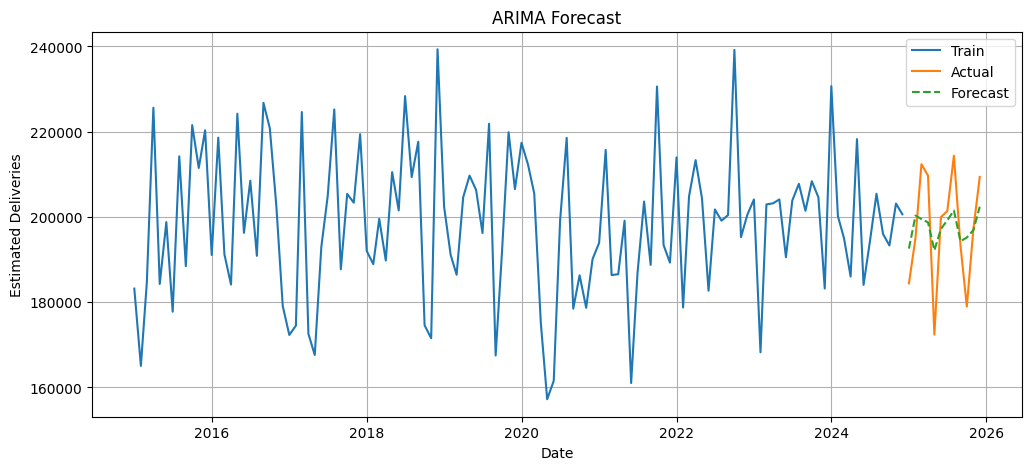

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Monthly deliveries
ts = df.groupby('Date')['Estimated_Deliveries'].sum()

# Log transformation
ts_log = np.log(ts)

# Check stationarity
result = adfuller(ts_log)
print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Not Stationary")

# Train-Test Split
train = ts_log[:-12]
test = ts_log[-12:]

# ARIMA Model
model = ARIMA(train, order=(4,0,5))
fit = model.fit()

# Forecast
forecast_log = fit.forecast(steps=len(test))

# Convert back to original values
forecast = np.exp(forecast_log)
actual = np.exp(test)

# Plot
plt.figure(figsize=(12,5))
plt.plot(train.index, np.exp(train), label='Train')
plt.plot(test.index, actual, label='Actual')
plt.plot(test.index, forecast, '--', label='Forecast')
plt.title("ARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.grid(True)
plt.show()



In [27]:
# Evaluation
mae = mean_absolute_error(actual, forecast)
mse = mean_squared_error(actual, forecast)
rmse = np.sqrt(mse)
r2 = r2_score(actual, forecast)

print("\nModel Performance")
print("MAE :", round(mae,2))
print("MSE :", round(mse,2))
print("RMSE:", round(rmse,2))
print("R²  :", round(r2,4))


Model Performance
MAE : 8265.11
MSE : 105063751.49
RMSE: 10250.06
R²  : 0.3652


## Conclusion

- Completed preprocessing and data cleaning.
- Performed EDA to identify trends and correlations.
- Engineered new predictive features.
- Built Linear Regression Ridge and Lasso models.
- Improved performance using hyperparameter tuning.
- Forecasted future Tesla deliveries using Holt-Winters Exponential Smoothing.
- Summarized business insights from regression and forecasting results.
